# Paso 1 — Exploración y preparación del corpus

Antes de calcular un solo embedding hay que saber **qué hay dentro de los datos**.
El proyecto anterior dejó esa lección grabada: el 44,8 % de duplicados de
UNSW-NB15 y el 25,3 % de fuga en su división oficial no aparecieron por intuición,
aparecieron por mirar.

Aquí se hace lo mismo con cuatro fuentes de ofertas de empleo descargadas de
Kaggle. **Una de las cuatro se va a descartar**, y el motivo es exactamente el
mismo problema.

## Lo que este cuaderno decide

1. **Qué fuentes entran** al corpus y cuáles no.
2. **Un esquema común**, porque las cuatro traen columnas distintas.
3. **Cuántas ofertas quedan de verdad** tras quitar duplicados.
4. **Cuánto texto está repetido** dentro de las descripciones — el *boilerplate*
   de empresa, que es un problema específico de la búsqueda semántica.


## 0. Preparación

Las rutas se calculan a partir de dónde se ejecute el cuaderno: **no hay ninguna
ruta absoluta**, así que el proyecto funciona clonado en cualquier carpeta.

In [1]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATOS = RAIZ / "datos"
SALIDA = DATOS / "procesado"
RESULTADOS = RAIZ / "resultados"
SALIDA.mkdir(exist_ok=True)
RESULTADOS.mkdir(exist_ok=True)

# Colores de la paleta del portafolio, para que los gráficos encajen.
ACENTO = "#5E6AD2"
AVISO = "#e0803c"
GRIS = "#8A8F98"

pd.set_option("display.width", 170)
pd.set_option("display.max_colwidth", 80)

print("Raíz del proyecto:", RAIZ.name)
print("\nArchivos en datos/:")
for archivo in sorted(DATOS.iterdir()):
    if archivo.is_file() and archivo.suffix in (".csv", ".ldjson", ".txt"):
        print(f"  {archivo.name:70} {archivo.stat().st_size / 1024**2:6.1f} MB")

Raíz del proyecto: Buscador semántico de ofertas de empleo

Archivos en datos/:
  Booking_Jobs_All_220218.csv                                               3.2 MB
  Booking_Jobs_All_220227.csv                                               3.2 MB
  Booking_Jobs_All_220312.csv                                               3.2 MB
  BusinessAnalyst.csv                                                      13.9 MB
  linkedin-jobs-africa.csv                                                  9.3 MB
  linkedin-jobs-canada.csv                                                 11.1 MB
  linkedin-jobs-usa.csv                                                    10.0 MB
  marketing_sample_for_seek_au-seek_au_jobs__20200101_20200331.txt         37.1 MB


---

# 1. La fuente que se descarta, y por qué

El primer conjunto descargado fueron tres CSV de ofertas de LinkedIn (África,
Canadá y EE. UU.). Suman **8 490 filas**, que sobre el papel es un buen tamaño.

Conviene comprobarlo antes de darlo por bueno.

In [2]:
linkedin = sorted(DATOS.glob("linkedin-jobs-*.csv"))

if linkedin:
    filas = []
    for archivo in linkedin:
        df = pd.read_csv(archivo, low_memory=False)
        descripciones = df["description"].astype(str)
        filas.append({
            "archivo": archivo.stem.replace("linkedin-jobs-", ""),
            "filas": len(df),
            "descripciones_unicas": descripciones.nunique(),
            "% único": round(descripciones.nunique() / len(df) * 100, 1),
            "títulos_únicos": df["title"].nunique(),
        })
    resumen_linkedin = pd.DataFrame(filas).set_index("archivo")
    print(resumen_linkedin.to_string())
    print(f"\nTotal de filas: {resumen_linkedin['filas'].sum():,}")
else:
    print("Los archivos de LinkedIn ya no están en datos/.")

         filas  descripciones_unicas  % único  títulos_únicos
archivo                                                      
africa    2872                   119      4.1              70
canada    2773                   166      6.0             104
usa       2845                   199      7.0              37

Total de filas: 8,490


In [3]:
# Las tres regiones, ¿traen ofertas distintas entre sí o repiten las mismas?
if linkedin:
    conjuntos = {}
    for archivo in linkedin:
        region = archivo.stem.replace("linkedin-jobs-", "")
        conjuntos[region] = set(pd.read_csv(archivo, low_memory=False)["description"].astype(str))

    union = set().union(*conjuntos.values())
    print(f"Descripciones únicas sumando las tres regiones: {len(union):,}")
    print(f"De un total de {resumen_linkedin['filas'].sum():,} filas "
          f"({len(union) / resumen_linkedin['filas'].sum() * 100:.1f}%)")

    regiones = list(conjuntos)
    print("\nOfertas compartidas entre regiones:")
    for i in range(len(regiones)):
        for j in range(i + 1, len(regiones)):
            a, b = regiones[i], regiones[j]
            print(f"  {a} ∩ {b}: {len(conjuntos[a] & conjuntos[b])}")

Descripciones únicas sumando las tres regiones: 480
De un total de 8,490 filas (5.7%)

Ofertas compartidas entre regiones:
  africa ∩ canada: 1
  africa ∩ usa: 1
  canada ∩ usa: 3


### Qué se ve aquí

**8 490 filas que contienen 480 descripciones distintas.** El 94 % del archivo es
repetición: África un 4,1 % de contenido único, Canadá un 6,0 %, EE. UU. un 7,0 %.

Y no se repiten *entre* regiones —comparten una o tres ofertas— sino **dentro de
cada una**: la misma oferta aparece decenas de veces.

Había además un segundo problema. Al mirar los títulos, casi todo era el mismo
puesto: `data analyst` con sus variantes, porque el dataset se llama literalmente
«LinkedIn **Data Analyst** Jobs». Para un buscador que debe distinguir entre tipos
de trabajo, un corpus de un solo tipo de trabajo no sirve.

> **Decisión: se descarta esta fuente.** Los archivos se dejan en `datos/` pero
> el código no vuelve a tocarlos.

Es el mismo hallazgo que en el proyecto anterior, y la misma lección: **el número
de filas no dice nada hasta que se cuentan las distintas.**

---

# 2. Las tres fuentes que sí entran

Traen columnas distintas, así que lo primero es llevarlas a un **esquema común**:

| Campo | Qué es |
|---|---|
| `fuente` | De dónde viene la oferta |
| `titulo` | Título del puesto |
| `descripcion` | El texto que se va a indexar |
| `empresa`, `ubicacion` | Contexto, no se indexa |
| `etiqueta` | La categoría que trae cada fuente, si la trae |

El campo `etiqueta` es el que permitirá medir más adelante. Cada fuente aporta
uno distinto, y eso condiciona para qué sirve cada una.

In [4]:
def cargar_seek():
    """Ofertas de Seek Australia. Vienen en ldjson: un JSON por línea."""
    # Al descomprimir se crea una carpeta que TAMBIÉN acaba en .ldjson, así que
    # hay que quedarse solo con archivos: abrir el directorio da PermissionError.
    candidatos = [
        r for patron in ("**/*seek_au*.ldjson", "*seek_au*.txt")
        for r in DATOS.glob(patron) if r.is_file()
    ]
    if not candidatos:
        return None
    registros = []
    with open(candidatos[0], encoding="utf-8") as f:
        for linea in f:
            if linea.strip():
                registros.append(json.loads(linea))
    df = pd.DataFrame(registros)
    return pd.DataFrame({
        "fuente": "seek_au",
        "titulo": df["job_title"],
        "descripcion": df["job_description"],
        "empresa": df["company_name"],
        "ubicacion": df["city"],
        # Seek no trae una categoría de puesto usable: su campo `category` son
        # cuatro valores de jornada laboral, no de función.
        "etiqueta": None,
    })


def cargar_booking():
    """Ofertas de Booking.com. Son tres capturas del mismo portal en fechas distintas."""
    archivos = sorted(DATOS.glob("Booking_Jobs_All_*.csv"))
    if not archivos:
        return None
    partes = []
    for archivo in archivos:
        df = pd.read_csv(archivo, low_memory=False)
        df["captura"] = archivo.stem[-6:]
        partes.append(df)
    df = pd.concat(partes, ignore_index=True)
    return pd.DataFrame({
        "fuente": "booking",
        "titulo": df["Job Title"],
        "descripcion": df["Job Description"],
        "empresa": "Booking.com",
        "ubicacion": df["Location"],
        # El equipo lo asigna una persona, no se deriva del título: es la
        # etiqueta más valiosa de todo el corpus.
        "etiqueta": df["Team"],
    })


def cargar_business_analyst():
    """Ofertas de analista de negocio, con el sector de la empresa."""
    archivo = DATOS / "BusinessAnalyst.csv"
    if not archivo.exists():
        return None
    df = pd.read_csv(archivo, low_memory=False)
    return pd.DataFrame({
        "fuente": "business_analyst",
        "titulo": df["Job Title"],
        "descripcion": df["Job Description"],
        "empresa": df["Company Name"],
        "ubicacion": df["Location"],
        "etiqueta": df["Sector"],
    })


partes = [f() for f in (cargar_seek, cargar_booking, cargar_business_analyst)]
crudo = pd.concat([p for p in partes if p is not None], ignore_index=True)

print(f"Filas cargadas: {len(crudo):,}\n")
print(crudo.groupby("fuente").size().to_string())

Filas cargadas: 11,924

fuente
booking             1985
business_analyst    4092
seek_au             5847


In [5]:
# El nombre de empresa de una de las fuentes trae la valoración pegada al final
# ("Memorial Sloan-Kettering\n3.9"). Se corta por el salto de línea.
crudo["empresa"] = crudo["empresa"].astype(str).str.split("\n").str[0].str.strip()

# Los valores ausentes vienen de formas distintas según la fuente: NaN, "-1", "".
crudo = crudo.replace({"etiqueta": {"-1": None, "": None}})
crudo["descripcion"] = crudo["descripcion"].astype(str)
crudo["titulo"] = crudo["titulo"].astype(str).str.strip()

resumen = pd.DataFrame({
    "ofertas": crudo.groupby("fuente").size(),
    "títulos_distintos": crudo.groupby("fuente")["titulo"].nunique(),
    "con_etiqueta": crudo.groupby("fuente")["etiqueta"].count(),
    "etiquetas_distintas": crudo.groupby("fuente")["etiqueta"].nunique(),
    "long_media_desc": crudo.groupby("fuente")["descripcion"].apply(
        lambda s: s.str.len().mean()).round(0),
})
resumen

,ofertas,títulos_distintos,con_etiqueta,etiquetas_distintas,long_media_desc
fuente,,,,,
booking,1985,810,1985,14,5007.0
business_analyst,4092,2210,3316,62,2963.0
seek_au,5847,4209,0,0,2919.0


### Qué aporta cada fuente

**Seek Australia** es la más grande y la más variada: 4 209 títulos distintos en
5 847 ofertas, de todo tipo de sector — administración, contabilidad, logística,
oficios, sanidad. Es lo que da **realismo al índice**. Su pega: no trae una
categoría de función aprovechable, porque el campo `category` resultó ser la
jornada laboral (`Full Time`, `Part Time`…), no el tipo de trabajo.

**Booking.com** es la pequeña pero la decisiva. Trae el campo **`Team`**, que
reparte las ofertas en 14 equipos y **lo asignó una persona, no se deduce del
título**. Esa independencia es justo lo que hace falta para medir sin trampas.

**Business Analyst** aporta 3 732 ofertas con el `Sector` de la empresa. Sirve de
masa adicional y como etiqueta secundaria.

---

# 3. Duplicados

Con la fuente de LinkedIn ya se vio lo que puede esconder un recuento de filas.
Toca aplicar la misma lupa a lo que queda.

Las tres capturas de Booking son del **mismo portal en tres fechas**, así que por
construcción van a repetir ofertas. La pregunta es cuántas.

In [6]:
def normalizar(texto):
    """Colapsa espacios y pasa a minúsculas, para comparar textos que solo
    difieren en formato."""
    return re.sub(r"\s+", " ", texto).strip().lower()


crudo["desc_norm"] = crudo["descripcion"].map(normalizar)

duplicados = pd.DataFrame({
    "ofertas": crudo.groupby("fuente").size(),
    "desc_exactas_únicas": crudo.groupby("fuente")["descripcion"].nunique(),
    "desc_normalizadas_únicas": crudo.groupby("fuente")["desc_norm"].nunique(),
})
duplicados["% duplicado"] = (
    (1 - duplicados["desc_normalizadas_únicas"] / duplicados["ofertas"]) * 100
).round(1)
duplicados

,ofertas,desc_exactas_únicas,desc_normalizadas_únicas,% duplicado
fuente,,,,
booking,1985,1352,819,58.7
business_analyst,4092,3732,3724,9.0
seek_au,5847,5604,5602,4.2


In [7]:
# Se conserva la primera aparición de cada descripción normalizada.
corpus = crudo.drop_duplicates(subset="desc_norm").reset_index(drop=True)
corpus["id"] = np.arange(len(corpus))

print(f"Antes:   {len(crudo):,} ofertas")
print(f"Después: {len(corpus):,} ofertas únicas "
      f"(-{(1 - len(corpus)/len(crudo))*100:.1f}%)\n")
print(corpus.groupby("fuente").size().to_string())

Antes:   11,924 ofertas
Después: 10,145 ofertas únicas (-14.9%)

fuente
booking              819
business_analyst    3724
seek_au             5602


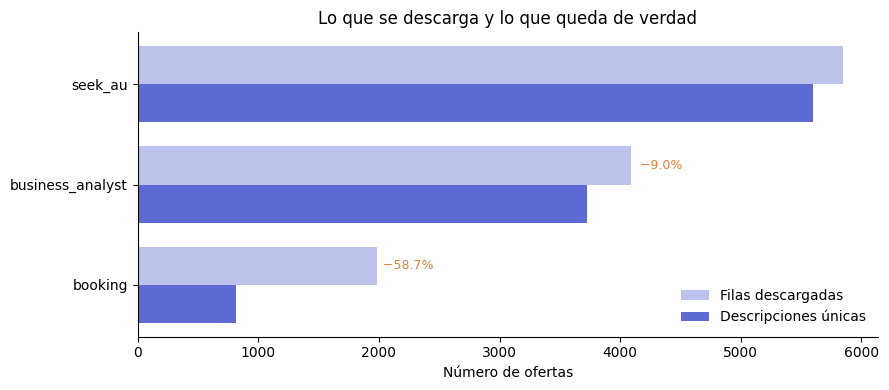

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
orden = duplicados.sort_values("ofertas").index
posicion = np.arange(len(orden))
alto = 0.38

ax.barh(posicion + alto / 2, duplicados.loc[orden, "ofertas"], alto,
        label="Filas descargadas", color=ACENTO, alpha=0.40)
ax.barh(posicion - alto / 2, duplicados.loc[orden, "desc_normalizadas_únicas"], alto,
        label="Descripciones únicas", color=ACENTO)

ax.set_yticks(posicion, orden)
ax.set_xlabel("Número de ofertas")
ax.set_title("Lo que se descarga y lo que queda de verdad")
ax.legend(frameon=False, loc="lower right")
ax.spines[["top", "right"]].set_visible(False)

for i, fuente in enumerate(orden):
    pct = duplicados.loc[fuente, "% duplicado"]
    if pct > 5:
        ax.text(duplicados.loc[fuente, "ofertas"] * 1.01, i + alto / 2,
                f" −{pct}%", va="center", fontsize=9, color=AVISO)

plt.tight_layout()
fig.savefig(RESULTADOS / "duplicados-por-fuente.png", dpi=140)
plt.show()

### Qué se ve aquí

**Booking pierde el 58,7 %**: de 1 985 filas quedan **819**. Era esperable —son
tres capturas del mismo portal con dos semanas de diferencia— pero el tamaño de
la caída no lo era.

Conviene fijarse en las dos columnas de únicos, porque la diferencia entre ellas
es un aviso:

- Descripciones **exactamente** iguales: quedan 1 352.
- Descripciones iguales **tras normalizar** espacios y mayúsculas: quedan 819.

**533 ofertas de Booking son la misma oferta con distinto formato.** Comparar
cadenas tal cual las habría dado por distintas y habrían entrado tres veces al
índice. Normalizar antes de deduplicar no es un detalle: cambia el resultado en
un 40 %.

**Seek y Business Analyst están limpias** — 4,2 % y 9,0 %.

Ninguna se acerca al 94 % de la fuente descartada, que es la comparación que
importa: **por eso aquella se va y estas se quedan.**

El corpus queda en **10 145 ofertas únicas**.

---

# 4. El texto repetido dentro de las descripciones

Este problema es propio de la búsqueda semántica y no aparece en un clasificador.

Muchas ofertas empiezan con varios párrafos idénticos sobre la empresa —«En
Booking.com los datos guían nuestras decisiones…»— antes de contar el puesto. Ese
texto no distingue nada, pero **sí ocupa espacio en el embedding**: si dos ofertas
comparten 800 caracteres de presentación corporativa, el modelo las verá
parecidas aunque una sea de ingeniería y otra de finanzas.

Conviene medir cuánto hay antes de decidir si se recorta.

In [9]:
def prefijo_compartido(serie, longitudes=(100, 200, 300, 500, 800, 1200)):
    """Para cada longitud, qué proporción de ofertas comparte su prefijo con otra."""
    filas = []
    for n in longitudes:
        prefijos = serie.str[:n]
        conteo = prefijos.value_counts()
        repetidos = conteo[conteo > 1]
        filas.append({
            "caracteres": n,
            "prefijos_repetidos": len(repetidos),
            "ofertas_afectadas": int(repetidos.sum()),
            "% del total": round(repetidos.sum() / len(serie) * 100, 1),
        })
    return pd.DataFrame(filas).set_index("caracteres")


for fuente in corpus["fuente"].unique():
    serie = corpus.loc[corpus["fuente"] == fuente, "desc_norm"]
    print(f"--- {fuente} ({len(serie):,} ofertas) ---")
    print(prefijo_compartido(serie).to_string())
    print()

--- seek_au (5,602 ofertas) ---
            prefijos_repetidos  ofertas_afectadas  % del total
caracteres                                                    
100                        154               1011         18.0
200                        126                942         16.8
300                         98                882         15.7
500                         60                799         14.3
800                         34                741         13.2
1200                        18                706         12.6

--- booking (819 ofertas) ---
            prefijos_repetidos  ofertas_afectadas  % del total
caracteres                                                    
100                         55                456         55.7
200                         57                447         54.6
300                         59                419         51.2
500                         63                308         37.6
800                         47                217      

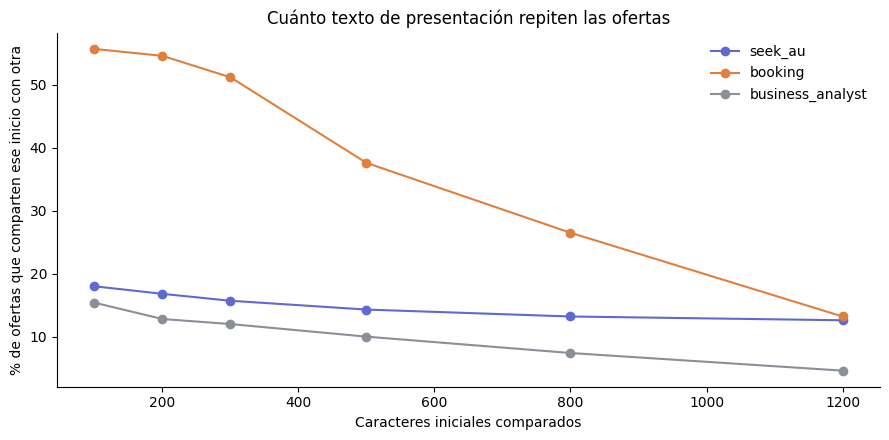

In [10]:
fig, ax = plt.subplots(figsize=(9, 4.5))

for fuente, color in zip(corpus["fuente"].unique(), [ACENTO, AVISO, GRIS]):
    serie = corpus.loc[corpus["fuente"] == fuente, "desc_norm"]
    tabla = prefijo_compartido(serie)
    ax.plot(tabla.index, tabla["% del total"], marker="o", color=color, label=fuente)

ax.set_xlabel("Caracteres iniciales comparados")
ax.set_ylabel("% de ofertas que comparten ese inicio con otra")
ax.set_title("Cuánto texto de presentación repiten las ofertas")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
fig.savefig(RESULTADOS / "texto-repetido.png", dpi=140)
plt.show()

### Qué se ve aquí — y es peor de lo que parecía

Las tres fuentes se comportan de forma muy distinta, y **la peor es justo la que
importa**.

| Caracteres iniciales compartidos | Booking | Seek | Business Analyst |
|---|---|---|---|
| 100 | **55,7 %** | 18,0 % | 15,4 % |
| 500 | **37,6 %** | 14,3 % | 10,0 % |
| 800 | **26,5 %** | 13,2 % | 7,4 % |
| 1 200 | 13,2 % | 12,6 % | 4,6 % |

**Más de la mitad de las ofertas de Booking empieza igual que otra**, y una de
cada cuatro comparte **800 caracteres idénticos** de presentación corporativa
antes de llegar al puesto.

Eso es un problema serio, y no por el volumen sino por dónde cae: **Booking es
exactamente el subconjunto que se va a usar como verdad de referencia**. Si un
cuarto de esas ofertas arranca con el mismo párrafo sobre la empresa, el embedding
de una oferta de Ingeniería y el de una de Finanzas van a parecerse por un motivo
que no tiene nada que ver con el puesto.

En Seek el porcentaje es menor pero **casi no baja al alargar la comparación**:
del 18 % al 12,6 %. Eso apunta a otro patrón — no plantillas de empresa, sino un
mismo anunciante publicando muchas ofertas con el texto calcado.

> **Consecuencia para el paso 4:** hay que medir **con y sin el texto compartido**.
> Recortarlo sin comprobar sería una corazonada; ignorarlo, con estos números,
> sería negligencia. La diferencia entre ambas mediciones es un resultado del
> proyecto, no un paso intermedio.

---

# 5. Longitud de las descripciones

Importa por una razón práctica: **los modelos de embeddings tienen un límite de
entrada**. El que se va a usar corta alrededor de las 256–512 palabras, así que si
las descripciones son mucho más largas, buena parte del texto **no se va a leer**.

Es una limitación real que hay que conocer antes, no descubrir después.

In [11]:
corpus["caracteres"] = corpus["descripcion"].str.len()
# Aproximación habitual en inglés: una palabra cada ~5 caracteres.
corpus["palabras_aprox"] = (corpus["caracteres"] / 5).round().astype(int)

longitud = corpus.groupby("fuente")["palabras_aprox"].describe(
    percentiles=[0.5, 0.9]
)[["count", "mean", "50%", "90%", "max"]].round(0)
longitud

,count,mean,50%,90%,max
fuente,,,,,
booking,819.0,984.0,920.0,1481.0,2757.0
business_analyst,3724.0,622.0,586.0,1116.0,3621.0
seek_au,5602.0,589.0,428.0,1387.0,3416.0


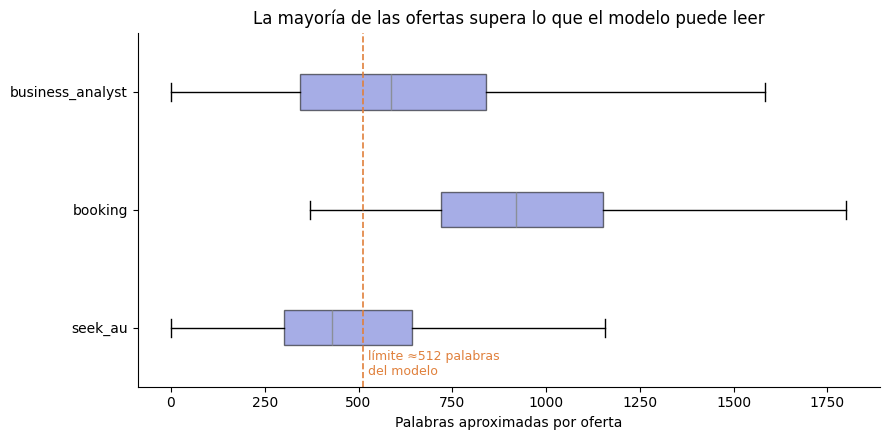

Ofertas que superan las ~512 palabras: 49.4%


In [12]:
fig, ax = plt.subplots(figsize=(9, 4.5))

datos = [corpus.loc[corpus["fuente"] == f, "palabras_aprox"].clip(upper=2500)
         for f in corpus["fuente"].unique()]
caja = ax.boxplot(datos, vert=False, patch_artist=True, showfliers=False,
                  tick_labels=list(corpus["fuente"].unique()))
for parche in caja["boxes"]:
    parche.set_facecolor(ACENTO)
    parche.set_alpha(0.55)
for mediana in caja["medians"]:
    mediana.set_color(GRIS)

# Límite típico de un modelo de embeddings pequeño.
ax.axvline(512, color=AVISO, linestyle="--", linewidth=1.2)
ax.text(525, 0.6, "límite ≈512 palabras\ndel modelo", fontsize=9, color=AVISO)

ax.set_xlabel("Palabras aproximadas por oferta")
ax.set_title("La mayoría de las ofertas supera lo que el modelo puede leer")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
fig.savefig(RESULTADOS / "longitud-ofertas.png", dpi=140)
plt.show()

supera = (corpus["palabras_aprox"] > 512).mean() * 100
print(f"Ofertas que superan las ~512 palabras: {supera:.1f}%")

### Qué se ve aquí

**El 49,4 % de las ofertas supera el límite del modelo** — prácticamente la mitad.
La línea naranja marca dónde deja de leer.

Pero el reparto no es uniforme, y ahí está lo interesante:

| Fuente | Mediana de palabras | ¿Supera el límite? |
|---|---|---|
| **Booking** | **920** | Casi siempre |
| Business Analyst | 586 | A menudo |
| Seek | 428 | Normalmente no |

**Las ofertas de Booking son las más largas del corpus**, con casi el doble de
palabras que las de Seek. Y otra vez es el subconjunto de la verdad de
referencia: si se trunca a 512 palabras, de una oferta típica de Booking **se
descarta la mitad**.

Peor aún, combinado con el apartado anterior: lo primero que se lee es la
presentación de la empresa —la parte compartida— y lo que se recorta es el final,
donde suelen estar los requisitos concretos del puesto. **Truncar sin más se
quedaría con lo genérico y tiraría lo distintivo.**

Eso obliga a una decisión en el paso 4, y conviene anticiparla:

- **Truncar** — quedarse con el principio. Simple, pero el principio es justo
  donde está la presentación de la empresa, o sea lo menos distintivo.
- **Trocear y promediar** — partir la oferta, codificar cada trozo y promediar.
  Más caro y difumina el significado.
- **Indexar por trozos** — cada trozo es un documento y la oferta se recupera si
  cualquiera de sus trozos coincide. Es lo que hace un RAG de verdad, y es
  justamente **lo que toca aprender en el proyecto 3**.

Se probará al menos truncar frente a trocear, con la medición delante.

---

# 6. La etiqueta que permitirá medir

Sin una verdad de referencia no se puede decir si un buscador es bueno. La pieza
que la hace posible está en Booking.

In [13]:
equipos = corpus.loc[corpus["fuente"] == "booking", "etiqueta"].value_counts()
print(f"Ofertas de Booking con equipo asignado: {equipos.sum():,}")
print(f"Equipos distintos: {len(equipos)}\n")
print(equipos.to_string())

Ofertas de Booking con equipo asignado: 819
Equipos distintos: 14

etiqueta
Engineering                       216
Business Development & Support    156
People                             94
Security & Infrastructure          61
Design & User Experience           48
Product                            47
Marketing & Communications         46
Data Science & Analytics           39
Customer Service                   38
Leadership                         27
Finance & Legal                    25
Finance                            10
IT Services                         7
Legal & Public Affairs              5


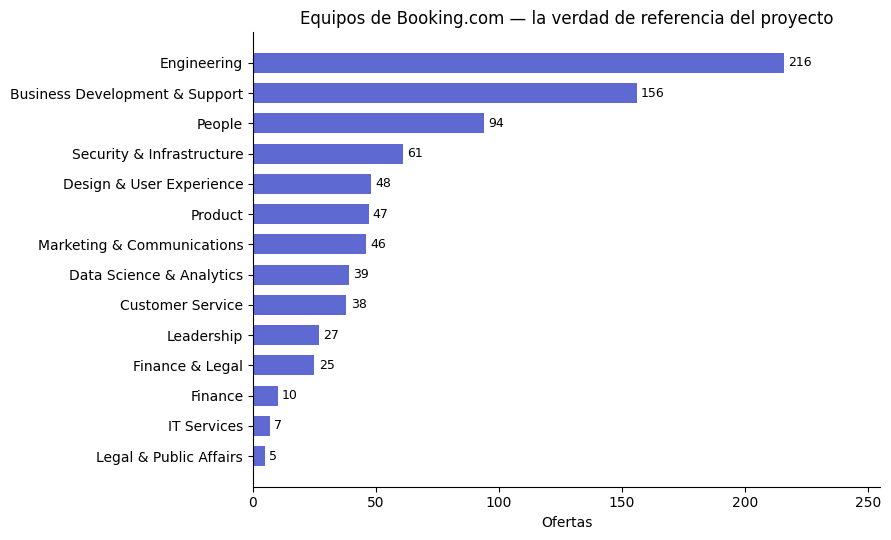

In [14]:
fig, ax = plt.subplots(figsize=(9, 5.5))
datos = equipos.sort_values()
barras = ax.barh(datos.index, datos.values, color=ACENTO, height=0.66)
ax.bar_label(barras, padding=3, fontsize=9)
ax.set_xlim(0, datos.max() * 1.18)
ax.set_xlabel("Ofertas")
ax.set_title("Equipos de Booking.com — la verdad de referencia del proyecto")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
fig.savefig(RESULTADOS / "equipos-booking.png", dpi=140)
plt.show()

### Por qué esta etiqueta y no el título del puesto

El plan inicial del proyecto era normalizar títulos (`Senior ML Engineer` →
`machine learning engineer`) y usar eso como verdad de referencia. **Al ver los
datos cambió**, por tres razones:

1. **`Team` lo asignó una persona.** No se deduce del texto de la oferta. Un
   título se puede acertar por coincidencia de palabras; el equipo, mucho menos.
   Eso hace la evaluación más exigente y más honesta.
2. **Normalizar títulos habría sido mi criterio**, no un dato. Decidir si
   `Analista de Datos Senior` y `Especialista en BI` son el mismo puesto es una
   opinión, y una opinión mía metida en la verdad de referencia contamina todo lo
   que se mida después.
3. **14 clases**, de 216 ofertas a 5.

### Lo que hay que arreglar y declarar

**El reparto es muy desigual.** `Engineering` tiene 216 ofertas y
`Legal & Public Affairs` solo 5. Con cinco documentos relevantes, un Recall@10 se
mueve en saltos del 20 % y una sola oferta cambia la cifra — el mismo aviso que
`Worms` en el proyecto anterior, y hay que repetirlo al reportar.

**Y hay categorías que se solapan:** `Finance & Legal` (25), `Finance` (10) y
`Legal & Public Affairs` (5) coexisten porque la taxonomía de Booking cambió
entre capturas. Unificarlas resuelve dos cosas a la vez: quita la ambigüedad y
sube la clase más pequeña a un tamaño medible.

### La limitación seria

**Todas las ofertas etiquetadas son de una misma empresa.** Comparten tono,
vocabulario y —como se acaba de medir— hasta 800 caracteres literales de
presentación. Un modelo podría aprender «esto suena a Booking» en vez de «esto es
de Ingeniería».

No invalida la medida —acertar la empresa pero no el equipo da 1 acierto de 14—
pero obliga a reportar **también** el resultado indexando solo Booking, para
separar los dos efectos. Queda anotado para el paso 3.

---

# 7. Guardado

Se guarda el corpus en Parquet: pesa la mitad que un CSV y conserva el tipo de
cada columna.

In [15]:
salida = corpus[
    ["id", "fuente", "titulo", "descripcion", "empresa", "ubicacion", "etiqueta", "caracteres"]
].copy()

destino = SALIDA / "corpus.parquet"
salida.to_parquet(destino, index=False)

print(f"{destino.name}: {len(salida):,} ofertas, "
      f"{destino.stat().st_size / 1024**2:.1f} MB\n")
print(salida.groupby("fuente").agg(
    ofertas=("id", "size"),
    con_etiqueta=("etiqueta", "count"),
).to_string())

corpus.parquet: 10,145 ofertas, 15.4 MB

                  ofertas  con_etiqueta
fuente                                 
booking               819           819
business_analyst     3724          3144
seek_au              5602             0


In [16]:
# Un vistazo final para comprobar que el texto llegó entero.
ejemplo = salida[salida["fuente"] == "booking"].iloc[0]
print(f"título:    {ejemplo['titulo']}")
print(f"equipo:    {ejemplo['etiqueta']}")
print(f"ubicación: {ejemplo['ubicacion']}")
print(f"\ndescripción ({ejemplo['caracteres']:,} caracteres), primeros 400:\n")
print(ejemplo["descripcion"][:400] + "…")

título:    Junior Endpoints Engineer
equipo:    Engineering
ubicación: Manchester, United Kingdom

descripción (6,748 caracteres), primeros 400:

Booking.com
It wasn’t so long ago that booking a trip to see the Eiffel Tower, stroll down New York’s iconic Madison Avenue or feel the sand between our toes on Copacabana Beach was simply a matter of a few taps on our smartphone.
In fact, that’s what we do at Booking.com. We make it easier for everyone to experience the world. And while that world might feel a little farther away right now, we’…


---

# Resumen

## Lo que había y lo que queda

| Fuente | Descargado | Útil | Decisión |
|---|---|---|---|
| LinkedIn (3 regiones) | 8 490 | **480** | ❌ **Descartada** |
| Seek Australia | 5 847 | 5 602 | ✅ Da realismo al índice |
| Booking.com (3 capturas) | 1 985 | **819** | ✅ **Aporta la verdad de referencia** |
| Business Analyst | 4 092 | 3 724 | ✅ Masa y etiqueta secundaria |

**Corpus final: 10 145 ofertas únicas.**

## Los cinco hallazgos

1. **Una fuente de cuatro era casi toda repetición.** 8 490 filas con 480
   descripciones distintas — un 94 % de duplicación. Y encima, todo el mismo
   puesto. Se descarta.

2. **Normalizar antes de deduplicar cambia el resultado en un 40 %.** En Booking,
   comparar las descripciones tal cual deja 1 352; normalizando espacios y
   mayúsculas quedan **819**. Son 533 ofertas que solo se diferenciaban en el
   formato.

3. **Más de la mitad de las ofertas de Booking empieza igual que otra**, y una de
   cada cuatro comparte 800 caracteres literales. Es el peor sitio donde podía
   pasar: Booking es la verdad de referencia. **Habrá que medir con y sin ese
   texto compartido.**

4. **El 49,4 % de las ofertas supera lo que el modelo puede leer**, y las de
   Booking son las más largas (mediana de 920 palabras). Truncar a 512 se
   quedaría con la presentación genérica y tiraría los requisitos concretos.

5. **La etiqueta está muy desequilibrada**: `Engineering` 216 frente a
   `Legal & Public Affairs` 5. Con cinco documentos relevantes, cada acierto
   mueve el Recall@10 un 20 %. Hay que decirlo al reportar, igual que con `Worms`
   en el proyecto anterior.

## Y una decisión de diseño que cambió al ver los datos

La verdad de referencia iba a construirse normalizando títulos de puesto. Pasa a
ser el campo **`Team` de Booking**: 14 equipos asignados por personas, no
deducidos del texto.

**El motivo de fondo:** normalizar títulos habría metido mi criterio dentro de la
verdad de referencia, y entonces cualquier cifra posterior mediría en parte mis
propias decisiones. `Team` es un dato, no una opinión.

## Siguiente paso

Redactar las consultas y montar la evaluación:

- **Unificar** `Finance & Legal`, `Finance` y `Legal & Public Affairs`.
- **Detectar y aislar el texto compartido** de Booking, para poder medir con y
  sin él.
- Escribir una consulta por equipo **sin usar el nombre del equipo ni palabras
  del título** — que es lo que pone a prueba la búsqueda semántica de verdad.
- Montar las métricas —Recall@10, MRR, nDCG@10— y el **control aleatorio**, que
  es el equivalente al `DummyClassifier` del proyecto anterior.
